<a href="https://colab.research.google.com/github/SasiEarni/CBOW-and-Skip-gram/blob/main/CBOW_vs_Skipgram_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as imp_pds
import warnings as nw
nw.filterwarnings('ignore')
import matplotlib.pyplot as news_plt
import numpy as np
from sklearn.model_selection import train_test_split
import time

In [3]:
#---------------------FAKE NEWS -----------------
fake_dframe = imp_pds.read_csv('/content/drive/MyDrive/CBOW_vs_Skipgram/Fake.csv')
#---------------------REAL NEWS -----------------
real_dframe = imp_pds.read_csv('/content/drive/MyDrive/CBOW_vs_Skipgram/True.csv')

In [4]:
# ---- FAKE DATASET INFO ----
print("FAKE DATASET SHAPE")
print("___________________")
print(fake_dframe.shape)

print("\nFAKE DATASET COLUMNS")
print("____________________")
print(fake_dframe.columns)


# ---- REAL DATASET INFO ----
print("\nREAL DATASET SHAPE")
print("___________________")
print(real_dframe.shape)

print("\nREAL DATASET COLUMNS")
print("____________________")
print(real_dframe.columns)

FAKE DATASET SHAPE
___________________
(23481, 4)

FAKE DATASET COLUMNS
____________________
Index(['title', 'text', 'subject', 'date'], dtype='object')

REAL DATASET SHAPE
___________________
(21417, 4)

REAL DATASET COLUMNS
____________________
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [5]:
# distribution of subject in fake news
fake_dframe['subject'].value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [6]:
# distribution of subject in real news
real_dframe['subject'].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


In [7]:
# ---- Add target column ----
fake_dframe['target'] = 'Fake news'
real_dframe['target'] = 'Real news'

# ---- Keep only required columns ----
fake_dframe = fake_dframe[['title', 'text', 'target']]
real_dframe = real_dframe[['title', 'text', 'target']]

***FAKE NEWS DATAFRAME***

In [8]:
fake_dframe

,title,text,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Fake news
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Fake news
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Fake news
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Fake news
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Fake news
...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Fake news
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Fake news
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Fake news
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Fake news


***REAL NEWS DATAFRAME***

In [9]:
real_dframe

,title,text,target
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,Real news
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,Real news
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,Real news
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,Real news
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,Real news
...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,Real news
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",Real news
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,Real news
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,Real news


***Merging Fake and Real News dataframes***

In [10]:
news_dframe = imp_pds.concat([fake_dframe, real_dframe], ignore_index=True)
news_dframe

,title,text,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Fake news
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Fake news
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Fake news
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Fake news
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Fake news
...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,Real news
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",Real news
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,Real news
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,Real news


In [11]:
news_dframe['target'].value_counts()

,count
target,
Fake news,23481
Real news,21417


In [12]:
news_dframe.describe().T

,count,unique,top,freq
title,44898,38729,Factbox: Trump fills top jobs for his administ...,14
text,44898,38646,,627
target,44898,2,Fake news,23481


# Cleaning Missing values and Duplicate entries - Initial Preprocessing

In [13]:
news_dframe.isnull().sum()

,0
title,0
text,0
target,0


In [14]:
print("Total Duplicate Entries:", news_dframe.duplicated().sum())

Total Duplicate Entries: 5793


In [15]:
# Drop duplicate rows
news_dframe = news_dframe.drop_duplicates()
news_dframe.shape  #shape after dropping duplicates

(39105, 3)

In [16]:
# Combine title and text into one column named 'text'
news_dframe.loc[:, 'text'] = news_dframe['title'] + " " + news_dframe['text']

# Drop title column
news_dframe.drop(columns=['title'], inplace=True)

# shuffle the dataframe
news_dframe = news_dframe.sample(frac=1, random_state=42).reset_index(drop=True)
news_dframe.head(10)

,text,target
0,Many 'lost' voters say they have found their c...,Real news
1,"Iranian Revolutionary Guards commander, anothe...",Real news
2,Cambodian leader gets China's backing as West ...,Real news
3,Ex-KKK Grand Wizard: Maine Gov. Right To Call...,Fake news
4,FINGER-WAGGING GRANNY HILLARY CLINTON Blows Up...,Fake news
5,Joe Scarborough Defends President Obama’s Emo...,Fake news
6,What Dan Rather Has To Say About Trump’s ‘Dea...,Fake news
7,"Republican: Porn Is Worse Than Cocaine, Gov’t...",Fake news
8,"Trump, under fire on many fronts, expands camp...",Real news
9,FLASHBACK: NANCY PELOSI Makes Outrageous Claim...,Fake news


In [17]:
news_dframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39105 entries, 0 to 39104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    39105 non-null  object
 1   target  39105 non-null  object
dtypes: object(2)
memory usage: 611.1+ KB


In [18]:
news_dframe['target'].value_counts()

,count
target,
Real news,21197
Fake news,17908


Real news data is more compared to fake news data

# Target column Analysis

In [19]:
nw_cnt = news_dframe['target'].value_counts()


PLOTTING BAR CHART...
______________________


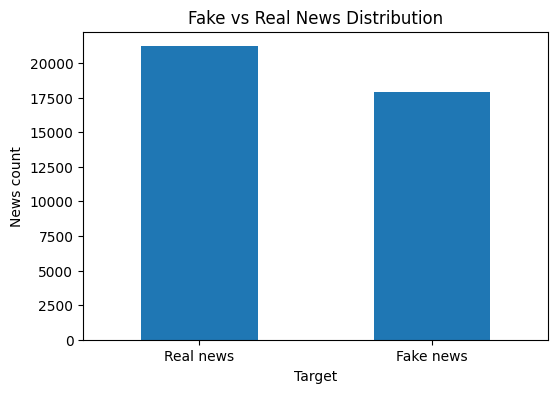

In [20]:
print("\nPLOTTING BAR CHART...")
print("______________________")

news_plt.figure(figsize=(6,4))
news_plt.title("Fake vs Real News Distribution")
nw_cnt.plot(kind='bar')
news_plt.xlabel("Target")
news_plt.ylabel("News count")
news_plt.xticks(rotation=0)
news_plt.show()


PLOTTING PIE CHART...
_____________________


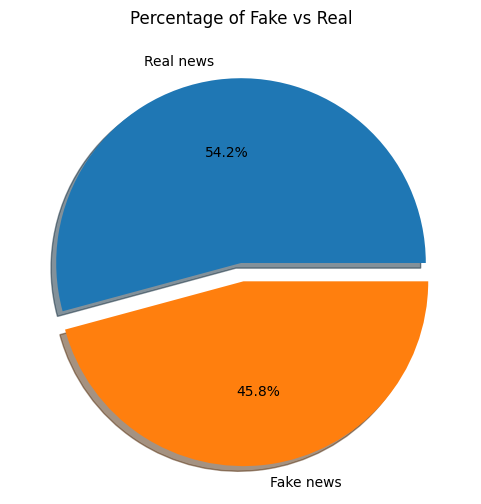

In [21]:
print("\nPLOTTING PIE CHART...")
print("_____________________")

news_plt.figure(figsize=(6,6))
news_plt.title("Percentage of Fake vs Real")
pie_exp = [0.1 if label == 'Fake news' else 0
           for label in nw_cnt.index]

news_plt.pie(nw_cnt, labels=nw_cnt.index, autopct='%1.1f%%', explode=pie_exp, shadow=True)
news_plt.show()

# *Cleaning the Text Data*

In [22]:
from IPython.display import display as nw_dply, Markdown as mrk_dwn

In [23]:
print("ORIGINAL NEWS TEXT (FIRST 2 RECORDS)")
print("____________________________________")

for i in range(2):
    nw_dply(mrk_dwn(f"**News {i+1}:**"))
    nw_dply(mrk_dwn(news_dframe['text'].iloc[i]))

ORIGINAL NEWS TEXT (FIRST 2 RECORDS)
____________________________________


**News 1:**

Many 'lost' voters say they have found their candidate in Trump WASHINGTON/NEW YORK (Reuters) - Ted Wade hasn’t cared about politics enough to cast a vote in a U.S. presidential election for almost a quarter of a century, back when he supported Ross Perot’s independent candidacy in 1992. But Republican Donald Trump’s 2016 White House bid has motivated Wade to get involved and he plans to support the real estate mogul in Nevada’s nominating caucus next month. Trump is a “non-politician” who can fix the “chaos” in Washington, he says. About one in 10 Americans who plan to cast a vote this election will do so for the first time in years, if ever, and Trump holds a decided edge with them, according to polling by Reuters/Ipsos. (tmsnrt.rs/1SgeLvi) These voters offer Trump a pool of voters who could be decisive either in the Republican primaries or a general election. They could be crucial for Trump in early-voting states such as Iowa and South Carolina, where his nearest rival, Senator Ted Cruz, is putting pressure on Trump and enjoys a strong base of support with more traditionally conservative voters. In Reuters/Ipsos polling from June to December 2015, 27.3 percent of these “new” voters said they would vote for Trump, higher than his poll numbers among independents and Republicans who regularly vote. By way of comparison, Cruz captures just 3.4 percent of these voters. And Senator Marco Rubio of Florida snags only 4 percent. “I’m tired of the chaos between Democrats and Republicans and want to give somebody a try who I think can make a difference,” said Wade of Trump. The 51-year-old has already switched his affiliation from Democrat to Republican and even attended a Trump campaign event in Las Vegas. He has told his three older children to get involved in the elections, although he did not say whether he wanted them to vote for Trump.  Trump, the Republican front-runner, has made targeting “lost” voters such as Wade a focus of his campaign. His anti-immigrant rhetoric and protectionist trade proposals have helped him to fashion a message tailored to reach Americans alienated by the endless enmity between the political parties and who, because of declining economic prospects, may feel like neither party has done much for them. Trump’s strategy is a gamble, given the lack of reliability of many of the voters with whom he is most popular. In interviews, some of those lost voters insist they will show up, saying they are drawn to Trump’s outsider status and his willingness to upend the political system. Tucson, Arizona, resident Renay Cunningham, 56, said she had never paid much attention to politics in the past. She plans to cast her first ever vote for Trump after hearing his proposed policies to curb illegal immigration, which include building a giant wall on the southern border and making Mexico pay for it. “We need a piranha in there, and he’s definitely a piranha,” she said. Trump and his operatives are confident they can do what few of his rivals for the Republican nomination have shown they can do — expand the party’s potential voter pool. But while Democrat Barack Obama did that eight years ago by largely registering new voters, including record levels of minorities, both male and female, in urban centers, Trump’s campaign has instead largely sought out the disaffected, who tend to be overwhelmingly older, white, and less educated than the broader electorate. “My whole campaign has been focused on expanding the number of people who want to, and will, participate in this election cycle,” Trump wrote in a recent op-ed in USA Today. When analyzing “lost” or “new” voters, Reuters compiled poll results from people who haven’t voted in the previous two presidential campaigns and midterm congressional elections. The results focused only on those who said they were nearly certain to vote in the November election. It included responses from 3,440 “new” Republican and independent voters – a sample that has a credibility interval of 2 percentage points. Jan Leighley, an expert on turnout at American University, said it’s too soon to compare Trump’s “new” voters with the disenfranchised voters, especially minorities, who in 2008 turned out in record numbers to elect the first black president. Those voters didn’t find their way to the polls simply because they were inspired to make history, Leighley said. “He also had a kick-ass mobilization structure.” “Obama’s campaign went door-to-door. They canvassed whole neighborhoods. “I don’t know if he (Trump) has the campaign infrastructure to make sure that the folks who are riled up are walked to the polls on Election Day,” she said. Trump’s campaign insists he does have the infrastructure, but won’t provide specifics on how it intends to turn casual supporters into engaged voters. The campaign says it does follow up with the thousands of attendees who jam arenas for Trump’s rallies. That’s one significant advantage the reality star has over the other candidates in the Republican field, as the challenge in reaching voters who have fallen out of the political process often lies in simply locating them. “We’ve identified a lot of people in early primary states who have not participated in the process before,” campaign manager Corey Lewandowski told Reuters. Lewandowski resists the notion that Trump needs to turn out “new” or reluctant voters to win states such as Iowa. Even if the Trump campaign isn’t necessarily counting on them, it may be reassuring that his supporters among “new” voters who responded to the Reuters/Ipsos survey appear motivated to cast a vote for him. At least for the time being. Ronald Thomas, a 49-year-old truck driver and Navy veteran in North Carolina, said he, too, has never voted in a presidential contest. His girlfriend would push him to vote but he would always say “Yeah, but the right one ain’t come along yet,’” Thomas said. Trump is that man. His willingness to take on the government has set him apart as someone who would “actually look out for the people,” said Thomas. Now he wants to know how to register so that he can vote for the billionaire.  And there’s Vince DiSylvester, a retired maintenance worker in Missouri, who, at 73, said has never cast a ballot for president. But Trump has inspired him to rethink that. “He’s a businessman, he knows business, he knows how to get things done,” he said. “And he tells it like it is. If you don’t like it - well, too bad.”  (Editing by Ross Colvin) SAP is the sponsor of this coverage which is independently produced by the staff of Reuters News Agency.

**News 2:**

Iranian Revolutionary Guards commander, another fighter, killed in Syria: Iranian media BEIRUT (Reuters) - A commander in Iran s elite Revolutionary Guards and a lower-ranking Iranian fighter have been killed fighting Islamic State in Syria in recent days, Iranian media reported on Sunday. The Revolutionary Guards, Iran s most powerful military force which also oversees an economic empire worth billions of dollars, have been fighting in support of Syrian president Bashar al-Assad for several years. An Iranian official told the Tasnim news agency last year that more than 1,000 Iranians have been killed in Syria. Senior members of the Guards have been among those killed. Kheyrollah Samadi, a Guards commander in charge of a unit in Syria, died on Thursday in fighting in the Albu Kamal region, bordering Iraq, according to Fars News. Samadi was killed in clashes with Islamic State, according to the Ghatreh news site. Iranian media have previously reported on fighting in that area between Iran s Shi ite militia allies and Islamic State. The Syrian army and its allies took complete control over Albu Kamal, Islamic State s last significant town in Syria, a military news service run by Hezbollah said on Sunday. Samadi, who fought in the Iran-Iraq war during the 1980s and had retired from the Iranian military before signing on to go to Syria, was killed by a mortar explosion, Fars News, a news agency, said. Iranian news sites posted pictures on Sunday of Samadi with Qassem Soleimani, head of the Guards branch responsible for operations outside Iran. The lower-ranking Iranian fighter, Mehdi Movahednia, was killed on Saturday in clashes with Islamic State in the town of Mayadin in eastern Syria, Fars News reported. The Revolutionary Guards initially kept quiet about their role in the Syria conflict. But in recent years, as casualties have mounted, they have been more outspoken about their engagement, framing it as an existential struggle against the Sunni Muslim fighters of Islamic State who see Shi ites, the majority of Iran s population, as apostates. On web sites linked to the Guards, members of the organization killed in Syria and Iraq are praised as protectors of Shi ite holy sites and labeled  defenders of the shrine . U.S. President Donald Trump last month gave the U.S. Treasury Department authority to impose economic sanctions on members of the Iranian Revolutionary Guard in response to what Washington calls its efforts to destabilize and undermine its opponents in the Middle East. 

Importing Libraries for Text cleaning

In [24]:
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Lowercasing, Hyphen & slash removal, URL removal, and Special character removal

In [25]:
def minimal_clean(news_txt):

    news_txt = news_txt.lower()                            # Lowercasing all characters
    news_txt = re.sub(r'[-/]', ' ', news_txt)              # Replacing hyphen (-) and slash (/) with space
    news_txt = re.sub(r'http\S+|www\S+', '', news_txt)     # Removing URLs / website links
    news_txt = re.sub(r'[^a-zA-Z\s]', '', news_txt)        # Special character removal
    news_token = word_tokenize(news_txt)

    return " ".join(news_token)

news_dframe['text'] = news_dframe['text'].apply(minimal_clean)

In [26]:
print("CLEANED TEXT (After Lowercasing, Hyphen & slash removal, URL removal, and Special character removal)")
print("__________________________________________________\n")

for i in range(2):
    nw_dply(mrk_dwn(f"**News {i+1}:**"))
    nw_dply(mrk_dwn(news_dframe['text'].iloc[i]))

CLEANED TEXT (After Lowercasing, Hyphen & slash removal, URL removal, and Special character removal)
__________________________________________________



**News 1:**

many lost voters say they have found their candidate in trump washington new york reuters ted wade hasnt cared about politics enough to cast a vote in a us presidential election for almost a quarter of a century back when he supported ross perots independent candidacy in but republican donald trumps white house bid has motivated wade to get involved and he plans to support the real estate mogul in nevadas nominating caucus next month trump is a non politician who can fix the chaos in washington he says about one in americans who plan to cast a vote this election will do so for the first time in years if ever and trump holds a decided edge with them according to polling by reuters ipsos tmsnrtrs sgelvi these voters offer trump a pool of voters who could be decisive either in the republican primaries or a general election they could be crucial for trump in early voting states such as iowa and south carolina where his nearest rival senator ted cruz is putting pressure on trump and enjoys a strong base of support with more traditionally conservative voters in reuters ipsos polling from june to december percent of these new voters said they would vote for trump higher than his poll numbers among independents and republicans who regularly vote by way of comparison cruz captures just percent of these voters and senator marco rubio of florida snags only percent im tired of the chaos between democrats and republicans and want to give somebody a try who i think can make a difference said wade of trump the year old has already switched his affiliation from democrat to republican and even attended a trump campaign event in las vegas he has told his three older children to get involved in the elections although he did not say whether he wanted them to vote for trump trump the republican front runner has made targeting lost voters such as wade a focus of his campaign his anti immigrant rhetoric and protectionist trade proposals have helped him to fashion a message tailored to reach americans alienated by the endless enmity between the political parties and who because of declining economic prospects may feel like neither party has done much for them trumps strategy is a gamble given the lack of reliability of many of the voters with whom he is most popular in interviews some of those lost voters insist they will show up saying they are drawn to trumps outsider status and his willingness to upend the political system tucson arizona resident renay cunningham said she had never paid much attention to politics in the past she plans to cast her first ever vote for trump after hearing his proposed policies to curb illegal immigration which include building a giant wall on the southern border and making mexico pay for it we need a piranha in there and hes definitely a piranha she said trump and his operatives are confident they can do what few of his rivals for the republican nomination have shown they can do expand the partys potential voter pool but while democrat barack obama did that eight years ago by largely registering new voters including record levels of minorities both male and female in urban centers trumps campaign has instead largely sought out the disaffected who tend to be overwhelmingly older white and less educated than the broader electorate my whole campaign has been focused on expanding the number of people who want to and will participate in this election cycle trump wrote in a recent op ed in usa today when analyzing lost or new voters reuters compiled poll results from people who havent voted in the previous two presidential campaigns and midterm congressional elections the results focused only on those who said they were nearly certain to vote in the november election it included responses from new republican and independent voters a sample that has a credibility interval of percentage points jan leighley an expert on turnout at american university said its too soon to compare trumps new voters with the disenfranchised voters especially minorities who in turned out in record numbers to elect the first black president those voters didnt find their way to the polls simply because they were inspired to make history leighley said he also had a kick ass mobilization structure obamas campaign went door to door they canvassed whole neighborhoods i dont know if he trump has the campaign infrastructure to make sure that the folks who are riled up are walked to the polls on election day she said trumps campaign insists he does have the infrastructure but wont provide specifics on how it intends to turn casual supporters into engaged voters the campaign says it does follow up with the thousands of attendees who jam arenas for trumps rallies thats one significant advantage the reality star has over the other candidates in the republican field as the challenge in reaching voters who have fallen out of the political process often lies in simply locating them weve identified a lot of people in early primary states who have not participated in the process before campaign manager corey lewandowski told reuters lewandowski resists the notion that trump needs to turn out new or reluctant voters to win states such as iowa even if the trump campaign isnt necessarily counting on them it may be reassuring that his supporters among new voters who responded to the reuters ipsos survey appear motivated to cast a vote for him at least for the time being ronald thomas a year old truck driver and navy veteran in north carolina said he too has never voted in a presidential contest his girlfriend would push him to vote but he would always say yeah but the right one aint come along yet thomas said trump is that man his willingness to take on the government has set him apart as someone who would actually look out for the people said thomas now he wants to know how to register so that he can vote for the billionaire and theres vince disylvester a retired maintenance worker in missouri who at said has never cast a ballot for president but trump has inspired him to rethink that hes a businessman he knows business he knows how to get things done he said and he tells it like it is if you dont like it well too bad editing by ross colvin sap is the sponsor of this coverage which is independently produced by the staff of reuters news agency

**News 2:**

iranian revolutionary guards commander another fighter killed in syria iranian media beirut reuters a commander in iran s elite revolutionary guards and a lower ranking iranian fighter have been killed fighting islamic state in syria in recent days iranian media reported on sunday the revolutionary guards iran s most powerful military force which also oversees an economic empire worth billions of dollars have been fighting in support of syrian president bashar al assad for several years an iranian official told the tasnim news agency last year that more than iranians have been killed in syria senior members of the guards have been among those killed kheyrollah samadi a guards commander in charge of a unit in syria died on thursday in fighting in the albu kamal region bordering iraq according to fars news samadi was killed in clashes with islamic state according to the ghatreh news site iranian media have previously reported on fighting in that area between iran s shi ite militia allies and islamic state the syrian army and its allies took complete control over albu kamal islamic state s last significant town in syria a military news service run by hezbollah said on sunday samadi who fought in the iran iraq war during the s and had retired from the iranian military before signing on to go to syria was killed by a mortar explosion fars news a news agency said iranian news sites posted pictures on sunday of samadi with qassem soleimani head of the guards branch responsible for operations outside iran the lower ranking iranian fighter mehdi movahednia was killed on saturday in clashes with islamic state in the town of mayadin in eastern syria fars news reported the revolutionary guards initially kept quiet about their role in the syria conflict but in recent years as casualties have mounted they have been more outspoken about their engagement framing it as an existential struggle against the sunni muslim fighters of islamic state who see shi ites the majority of iran s population as apostates on web sites linked to the guards members of the organization killed in syria and iraq are praised as protectors of shi ite holy sites and labeled defenders of the shrine us president donald trump last month gave the us treasury department authority to impose economic sanctions on members of the iranian revolutionary guard in response to what washington calls its efforts to destabilize and undermine its opponents in the middle east

# Lemmatization

In [27]:
nw_lemmatize = WordNetLemmatizer()

def nw_lemmatization(news_txt):
    news_token = word_tokenize(news_txt)
    news_token = [nw_lemmatize.lemmatize(word) for word in news_token]

    return " ".join(news_token)

news_dframe['text'] = news_dframe['text'].apply(nw_lemmatization)

In [28]:
print("\nLEMMATIZED NEWS")
print("________________\n")

for i in range(2):
    nw_dply(mrk_dwn(f"**News {i+1}:**"))
    nw_dply(mrk_dwn(news_dframe['text'].iloc[i]))


LEMMATIZED NEWS
________________



**News 1:**

many lost voter say they have found their candidate in trump washington new york reuters ted wade hasnt cared about politics enough to cast a vote in a u presidential election for almost a quarter of a century back when he supported ross perots independent candidacy in but republican donald trump white house bid ha motivated wade to get involved and he plan to support the real estate mogul in nevada nominating caucus next month trump is a non politician who can fix the chaos in washington he say about one in american who plan to cast a vote this election will do so for the first time in year if ever and trump hold a decided edge with them according to polling by reuters ipsos tmsnrtrs sgelvi these voter offer trump a pool of voter who could be decisive either in the republican primary or a general election they could be crucial for trump in early voting state such a iowa and south carolina where his nearest rival senator ted cruz is putting pressure on trump and enjoys a strong base of support with more traditionally conservative voter in reuters ipsos polling from june to december percent of these new voter said they would vote for trump higher than his poll number among independent and republican who regularly vote by way of comparison cruz capture just percent of these voter and senator marco rubio of florida snag only percent im tired of the chaos between democrat and republican and want to give somebody a try who i think can make a difference said wade of trump the year old ha already switched his affiliation from democrat to republican and even attended a trump campaign event in la vega he ha told his three older child to get involved in the election although he did not say whether he wanted them to vote for trump trump the republican front runner ha made targeting lost voter such a wade a focus of his campaign his anti immigrant rhetoric and protectionist trade proposal have helped him to fashion a message tailored to reach american alienated by the endless enmity between the political party and who because of declining economic prospect may feel like neither party ha done much for them trump strategy is a gamble given the lack of reliability of many of the voter with whom he is most popular in interview some of those lost voter insist they will show up saying they are drawn to trump outsider status and his willingness to upend the political system tucson arizona resident renay cunningham said she had never paid much attention to politics in the past she plan to cast her first ever vote for trump after hearing his proposed policy to curb illegal immigration which include building a giant wall on the southern border and making mexico pay for it we need a piranha in there and he definitely a piranha she said trump and his operative are confident they can do what few of his rival for the republican nomination have shown they can do expand the party potential voter pool but while democrat barack obama did that eight year ago by largely registering new voter including record level of minority both male and female in urban center trump campaign ha instead largely sought out the disaffected who tend to be overwhelmingly older white and less educated than the broader electorate my whole campaign ha been focused on expanding the number of people who want to and will participate in this election cycle trump wrote in a recent op ed in usa today when analyzing lost or new voter reuters compiled poll result from people who havent voted in the previous two presidential campaign and midterm congressional election the result focused only on those who said they were nearly certain to vote in the november election it included response from new republican and independent voter a sample that ha a credibility interval of percentage point jan leighley an expert on turnout at american university said it too soon to compare trump new voter with the disenfranchised voter especially minority who in turned out in record number to elect the first black president those voter didnt find their way to the poll simply because they were inspired to make history leighley said he also had a kick as mobilization structure obamas campaign went door to door they canvassed whole neighborhood i dont know if he trump ha the campaign infrastructure to make sure that the folk who are riled up are walked to the poll on election day she said trump campaign insists he doe have the infrastructure but wont provide specific on how it intends to turn casual supporter into engaged voter the campaign say it doe follow up with the thousand of attendee who jam arena for trump rally thats one significant advantage the reality star ha over the other candidate in the republican field a the challenge in reaching voter who have fallen out of the political process often lie in simply locating them weve identified a lot of people in early primary state who have not participated in the process before campaign manager corey lewandowski told reuters lewandowski resists the notion that trump need to turn out new or reluctant voter to win state such a iowa even if the trump campaign isnt necessarily counting on them it may be reassuring that his supporter among new voter who responded to the reuters ipsos survey appear motivated to cast a vote for him at least for the time being ronald thomas a year old truck driver and navy veteran in north carolina said he too ha never voted in a presidential contest his girlfriend would push him to vote but he would always say yeah but the right one aint come along yet thomas said trump is that man his willingness to take on the government ha set him apart a someone who would actually look out for the people said thomas now he want to know how to register so that he can vote for the billionaire and there vince disylvester a retired maintenance worker in missouri who at said ha never cast a ballot for president but trump ha inspired him to rethink that he a businessman he know business he know how to get thing done he said and he tell it like it is if you dont like it well too bad editing by ross colvin sap is the sponsor of this coverage which is independently produced by the staff of reuters news agency

**News 2:**

iranian revolutionary guard commander another fighter killed in syria iranian medium beirut reuters a commander in iran s elite revolutionary guard and a lower ranking iranian fighter have been killed fighting islamic state in syria in recent day iranian medium reported on sunday the revolutionary guard iran s most powerful military force which also oversees an economic empire worth billion of dollar have been fighting in support of syrian president bashar al assad for several year an iranian official told the tasnim news agency last year that more than iranian have been killed in syria senior member of the guard have been among those killed kheyrollah samadi a guard commander in charge of a unit in syria died on thursday in fighting in the albu kamal region bordering iraq according to far news samadi wa killed in clash with islamic state according to the ghatreh news site iranian medium have previously reported on fighting in that area between iran s shi ite militia ally and islamic state the syrian army and it ally took complete control over albu kamal islamic state s last significant town in syria a military news service run by hezbollah said on sunday samadi who fought in the iran iraq war during the s and had retired from the iranian military before signing on to go to syria wa killed by a mortar explosion far news a news agency said iranian news site posted picture on sunday of samadi with qassem soleimani head of the guard branch responsible for operation outside iran the lower ranking iranian fighter mehdi movahednia wa killed on saturday in clash with islamic state in the town of mayadin in eastern syria far news reported the revolutionary guard initially kept quiet about their role in the syria conflict but in recent year a casualty have mounted they have been more outspoken about their engagement framing it a an existential struggle against the sunni muslim fighter of islamic state who see shi ites the majority of iran s population a apostate on web site linked to the guard member of the organization killed in syria and iraq are praised a protector of shi ite holy site and labeled defender of the shrine u president donald trump last month gave the u treasury department authority to impose economic sanction on member of the iranian revolutionary guard in response to what washington call it effort to destabilize and undermine it opponent in the middle east

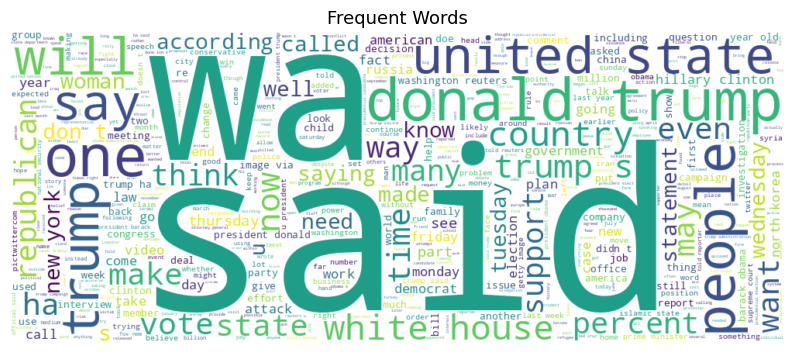

In [29]:
from wordcloud import WordCloud as nw_cloud

news_plt.figure(figsize=(10, 5), facecolor=None)
nw_one_string = ' '.join([txt for txt in news_dframe['text']]) # Combine all news text into one string
nw_wordcloud = nw_cloud(max_words=500,
                           width=1000,
                           height=400,
                           background_color='white',
                           colormap='viridis'
).generate(nw_one_string)

news_plt.imshow(nw_wordcloud, interpolation='bilinear')
news_plt.axis('off')
news_plt.title("Frequent Words", fontsize=13)
news_plt.show()

In [30]:
# Convert target to binary
news_dframe['target'] = news_dframe['target'].map({'Fake news': 0, 'Real news': 1})
print(news_dframe['target'].value_counts())

target
1    21197
0    17908
Name: count, dtype: int64


In [31]:
news_dframe.shape

(39105, 2)

In [32]:
news_dframe.head(10)

,text,target
0,many lost voter say they have found their cand...,1
1,iranian revolutionary guard commander another ...,1
2,cambodian leader get china backing a west cond...,1
3,ex kkk grand wizard maine gov right to call ou...,0
4,finger wagging granny hillary clinton blow up ...,0
5,joe scarborough defends president obamas emoti...,0
6,what dan rather ha to say about trump deadly s...,0
7,republican porn is worse than cocaine govt ha ...,0
8,trump under fire on many front expands campaig...,1
9,flashback nancy pelosi make outrageous claim a...,0


In [33]:
news_dframe.to_csv('/news.csv', index=False)

In [34]:
news_dframe = imp_pds.read_csv('/content/drive/MyDrive/CBOW_vs_Skipgram/news.csv')
news_dframe

,text,target
0,many lost voter say they have found their cand...,1
1,iranian revolutionary guard commander another ...,1
2,cambodian leader get china backing a west cond...,1
3,ex kkk grand wizard maine gov right to call ou...,0
4,finger wagging granny hillary clinton blow up ...,0
...,...,...
39100,hillary message to former miss universe called...,0
39101,senior cia intel wiretapping of trump transiti...,0
39102,ex georgian leader saakashvili barge across uk...,1
39103,trump stole an idea from north korean propagan...,0


In [35]:
# 80% data alloted for training and remaining 20%  for testing
X_news = news_dframe['text']
y_target = news_dframe['target']

X_train_news, X_test_news, y_train, y_test = train_test_split(
    X_news, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)
print("Number of rows with news in training set:", len(X_train_news))
print("Number of rows with news in testing set:", len(X_test_news))

Number of rows with news in training set: 31284
Number of rows with news in testing set: 7821


In [36]:
# Tokenize the news text data
X_train_tok = [text.split() for text in X_train_news]
X_test_tok = [text.split() for text in X_test_news]

print("First two rows of news in the training data which are tokenized:\n")
for i in range(2):
    print(f"News {i+1}:", X_train_tok[i])
    print()

First two rows of news in the training data which are tokenized:

News 1: ['bigot', 'upset', 'their', 'daughter', 'wa', 'taught', 'world', 'history', 'suing', 'maryland', 'public', 'school', 'john', 'and', 'melissa', 'wood', 'are', 'typical', 'right', 'wing', 'loon', 'after', 'their', 'daughter', 'told', 'them', 'about', 'her', 'class', 'assignment', 'john', 'wood', 'set', 'off', 'to', 'laplata', 'high', 'school', 'in', 'maryland', 'in', 'a', 'fit', 'of', 'rage', 'his', 'daughter', 'it', 'seems', 'wa', 'taught', 'about', 'islam', 'a', 'part', 'of', 'a', 'world', 'history', 'course', 'which', 'didn', 't', 'sit', 'well', 'with', 'the', 'bigoted', 'former', 'marine', 'or', 'his', 'wifeaccording', 'to', 'the', 'wood', 'their', 'daughter', 'wa', 'forced', 'to', 'accept', 'islam', 'a', 'her', 'one', 'true', 'religion', 'and', 'wa', 'forced', 'to', 'memorize', 'the', 'five', 'tenet', 'of', 'the', 'faith', 'they', 'argued', 'that', 'the', 'class', 'only', 'spent', 'a', 'single', 'day', 'on', '

**TF-IDF**

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_news)
X_test_tfidf = tfidf.transform(X_test_news)

print("Training data shape with TF-IDF:", X_train_tfidf.shape)
print("Testing data shape with TF-IDF:", X_test_tfidf.shape)

Training data shape with TF-IDF: (31284, 300)
Testing data shape with TF-IDF: (7821, 300)


**Logistic Regression + GridSearchCV**

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import (confusion_matrix as cm_news, classification_report as cl_report, roc_auc_score as auc_news, roc_curve as roc_news)
from sklearn.metrics import ConfusionMatrixDisplay as display_cm

In [39]:
model_log_reg = LogisticRegression()

set_para = {
    'C': [0.001, 0.01, 0.1],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [50]
}

# GridSearchCV
gridcv_tuning = GridSearchCV(
    model_log_reg,
    set_para,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

start_lr_time = time.time()
gridcv_tuning.fit(X_train_tfidf, y_train)
lr_training_time = time.time() - start_lr_time

print("\nBest parameters of LR:", gridcv_tuning.best_params_)
print("Best cv score:", gridcv_tuning.best_score_)
print(f"Training time of LR: {lr_training_time:.4f} seconds")


Best parameters of LR: {'C': 0.1, 'max_iter': 50, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cv score: 0.9625367600051145
Training time of LR: 3.5567 seconds



Training accuracy of LR: 0.9691535609257128

Testing time: 0.0059 seconds


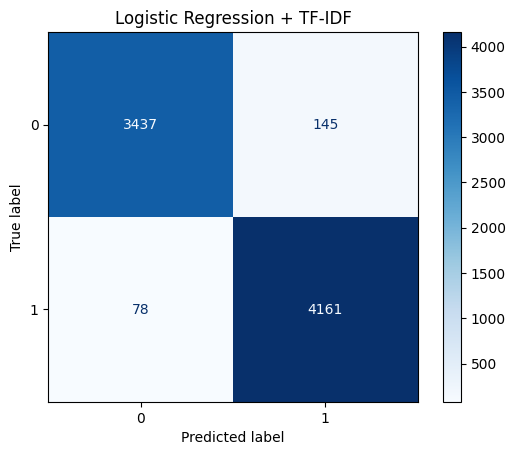

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3582
           1       0.97      0.98      0.97      4239

    accuracy                           0.97      7821
   macro avg       0.97      0.97      0.97      7821
weighted avg       0.97      0.97      0.97      7821


ROC-AUC Score: 0.9947


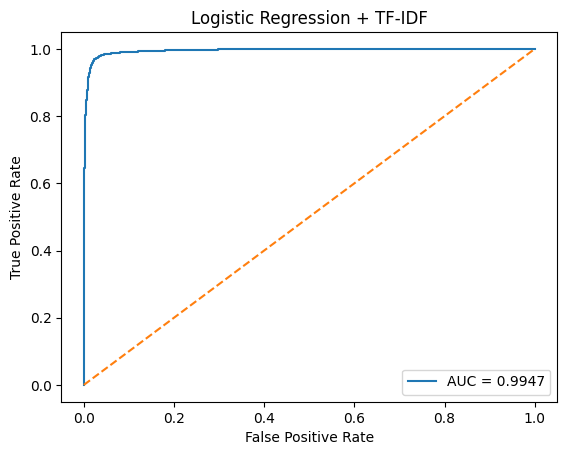

In [40]:
bst_lr_reg_model = gridcv_tuning.best_estimator_
y_train_pred = bst_lr_reg_model.predict(X_train_tfidf)

train_acc = accuracy_score(y_train, y_train_pred)
print("\nTraining accuracy of LR:", train_acc)

# Testing
start_time = time.time()
y_pred = bst_lr_reg_model.predict(X_test_tfidf)
y_prob = bst_lr_reg_model.predict_proba(X_test_tfidf)[:, 1]
prediction_time = time.time() - start_time
print(f"\nTesting time: {prediction_time:.4f} seconds")

news_cm_display = display_cm(cm_news(y_test, y_pred))
news_cm_display.plot(cmap='Blues')
news_plt.title("Logistic Regression + TF-IDF")
news_plt.show()

print(cl_report(y_test, y_pred))

auc_score = auc_news(y_test, y_prob)
print(f"\nROC-AUC Score: {auc_score:.4f}")

fpr, tpr, _ = roc_news(y_test, y_prob)
news_plt.figure()
news_plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
news_plt.plot([0, 1], [0, 1], linestyle='--')
news_plt.xlabel("False Positive Rate")
news_plt.ylabel("True Positive Rate")
news_plt.title("Logistic Regression + TF-IDF")
news_plt.legend()
news_plt.show()

# Word2Vec with CBOW

In [41]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.1 MB/s eta 0:00:00


In [42]:
from gensim.models import Word2Vec

# Training Word2Vec with CBOW

In [43]:
#Training Word2Vec with CBOW ONLY on training data
start_cbow_time = time.time()

cbow_model = Word2Vec(
    sentences=X_train_tok,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=0  #Cbow
)

cbow_training_time = time.time() - start_cbow_time

print(f"\nCBOW Training Time: {cbow_training_time:.4f} seconds")


CBOW Training Time: 203.3268 seconds


In [44]:
# keras tokeniser for the LSTM input
from tensorflow.keras.preprocessing.text import Tokenizer as keras_tokenizer

keras_token_news = keras_tokenizer()
keras_token_news.fit_on_texts(X_train_news)
X_train_seq = keras_token_news.texts_to_sequences(X_train_news)
X_test_seq = keras_token_news.texts_to_sequences(X_test_news)

print("First two rows of news in the training data after word2vec and tokenisation with keras:\n")
for i in range(2):
    print(f"News {i+1}:", X_train_seq[i])
    print()

First two rows of news in the training data after word2vec and tokenisation with keras:

News 1: [3223, 2398, 41, 1062, 17, 4533, 187, 553, 5352, 2909, 192, 315, 371, 5, 7601, 3671, 28, 3697, 88, 887, 14220, 51, 41, 1062, 91, 101, 39, 57, 911, 7114, 371, 3671, 361, 229, 2, 63665, 329, 315, 6, 2909, 6, 3, 2111, 4, 4326, 18, 1062, 12, 831, 17, 4533, 39, 1645, 3, 195, 4, 3, 187, 553, 515, 52, 437, 46, 1975, 182, 16, 1, 3629, 112, 2197, 50, 18, 63666, 2, 1, 3671, 41, 1062, 17, 963, 2, 1416, 1645, 3, 57, 53, 874, 1489, 5, 17, 963, 2, 31450, 1, 492, 8991, 4, 1, 1885, 31, 1606, 7, 1, 911, 109, 946, 3, 906, 113, 8, 4968, 5, 172, 1524, 8, 2, 97, 116, 4, 339, 63667, 2, 16696, 205, 6, 1, 515, 4, 3, 553, 911, 11, 61, 135, 45, 35, 223, 6521, 33, 1, 3535, 427, 12, 75, 4464, 7, 54, 17, 120, 963, 2, 7040, 2, 1645, 7, 15, 439, 2, 1, 315, 5, 1224, 1, 6419, 4795, 6, 30, 1791, 425, 24, 1, 1323, 5, 3, 71, 25509, 247, 24, 454, 108, 46919, 1, 315, 8495, 7, 1, 964, 4, 1, 715, 441, 46, 2111, 1, 2193, 1, 3223, 

In [45]:
from tensorflow.keras.preprocessing.sequence import pad_sequences as pad_seq

#padding for LSTM
X_train = pad_seq(X_train_seq, maxlen= 200)
X_test = pad_seq(X_test_seq, maxlen= 200)

print("First two rows of news after padding:\n")
for i in range(2):
    print(f"News {i+1}:", X_train[i])
    print()

First two rows of news after padding:

News 1: [  103   487     7  1786     2   467   152  1123     6   731  2775   127
    12    10   332   635     9 10467   135  1983  1594     1  2230  3482
    11    26     1   515    62  4533  1267   162   190     3  6522    11
     1   274  1165 27089    19   731     5  1645    11     3  1489     4
   661   188     2   177    45     3  1489     4     3   300    45    28
    56     2  1228    27    58  1237    55     7    48   874    31    35
   109    23     2   118    39    45   676     2  1228    58   763   226
    43    23     2  2070   263    12  2240    46   830   319    43    62
    23     2  2070   111    45    70   499     2   223  1645     3 21221
  1489    64     1  3916  3150   381    24    17  1281  9120    24 34762
   695     4  6961  1159     1 14483     4     1  1885     2    18  3916
     5  1341     4  8934 12515     4 63668  2172     7    24     3   329
   315   187   553 39527  3671    28  1096     9 28987  1834  4587     1
  44

In [46]:
#Embedding Matrix

vocab_size = len(keras_token_news.word_index) + 1

def lstm_embed_matrix(model):
    embedding_matrix = np.zeros((vocab_size, 300))
    for word, i in keras_token_news.word_index.items():
        if word in model.wv:
            embedding_matrix[i] = model.wv[word]
    return embedding_matrix

cbow_embed_matrix = lstm_embed_matrix(cbow_model)
print("Embedding Matrix Shape:", cbow_embed_matrix.shape)

Embedding Matrix Shape: (161005, 300)


# LSTM trained with text data embedded using word2vec with cbow (without PCA dimensionality reduction)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [48]:
lstm_model_cbow = Sequential()

lstm_model_cbow.add(Embedding(
    input_dim=vocab_size,
    output_dim=300,
    weights=[cbow_embed_matrix],
    input_length=200,
    trainable=False
))

lstm_model_cbow.add(LSTM(64))
lstm_model_cbow.add(Dense(1, activation='sigmoid'))

lstm_model_cbow.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

start_lstm_train = time.time()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = lstm_model_cbow.fit(
    X_train, y_train,
    validation_split=0.2,   # takes 20% of training data for validation
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

lstm_training_time = time.time() - start_lstm_train
print(f"\nLSTM Training Time: {lstm_training_time:.4f} seconds")

Epoch 1/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 114s 282ms/step - accuracy: 0.9527 - loss: 0.1265 - val_accuracy: 0.9784 - val_loss: 0.0698
Epoch 2/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 137s 269ms/step - accuracy: 0.9829 - loss: 0.0521 - val_accuracy: 0.9835 - val_loss: 0.0505
Epoch 3/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 105s 269ms/step - accuracy: 0.9887 - loss: 0.0356 - val_accuracy: 0.9826 - val_loss: 0.0537
Epoch 4/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 114s 292ms/step - accuracy: 0.9930 - loss: 0.0227 - val_accuracy: 0.9856 - val_loss: 0.0450
Epoch 5/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 114s 290ms/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9867 - val_loss: 0.0473
Epoch 6/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 107s 272ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 0.9872 - val_loss: 0.0458

LSTM Training Time: 691.5816 seconds


245/245 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step

Testing (Prediction) time: 19.2528 seconds


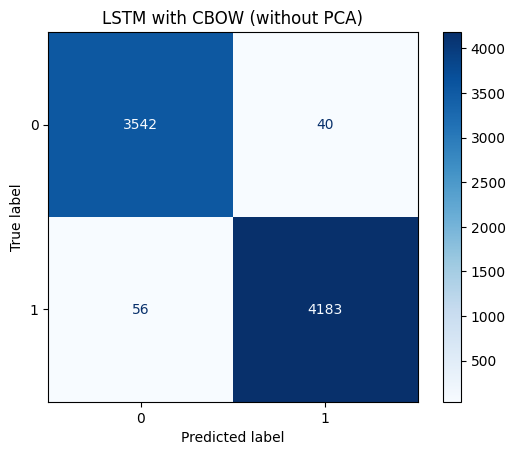

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3582
           1       0.99      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821


ROC-AUC Score: 0.9985


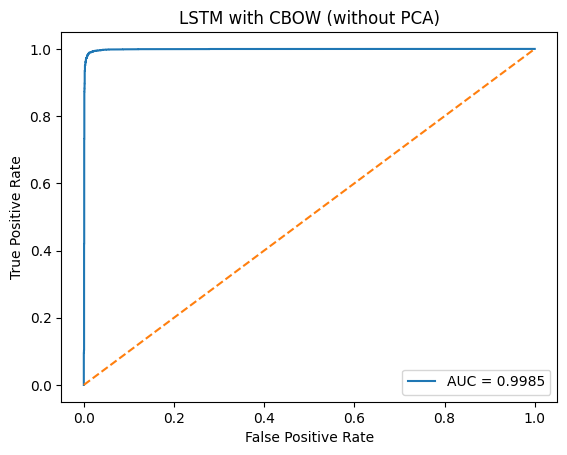

In [49]:
# Testing LSTM
start_lstm_tst_time = time.time()
y_pred_prob = lstm_model_cbow.predict(X_test)
lstm_predict_time = time.time() - start_lstm_tst_time
print(f"\nTesting (Prediction) time: {lstm_predict_time:.4f} seconds")


# Converting Probabilities to Class labels
y_pred_prob = y_pred_prob.ravel()   # flatten
y_pred = (y_pred_prob > 0.5).astype(int)


# Confusion Matrix
news_cm_display = display_cm(cm_news(y_test, y_pred))   # Confusion Matrix
news_cm_display.plot(cmap='Blues')
news_plt.title("LSTM with CBOW (without PCA)")
news_plt.show()

# ---------   Classifcation report with accuracy, precision, recall  and f1 score
print(cl_report(y_test, y_pred))

# ---------   Measuring the ROC-AUC Score and Plotting the ROC Curve

auc_score = auc_news(y_test, y_pred_prob)   # ROC-AUC Score
print(f"\nROC-AUC Score: {auc_score:.4f}")


fpr, tpr, thresholds = roc_news(y_test, y_pred_prob)
news_plt.figure()
news_plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
news_plt.plot([0, 1], [0, 1], linestyle='--')
news_plt.xlabel("False Positive Rate")
news_plt.ylabel("True Positive Rate")
news_plt.title("LSTM with CBOW (without PCA)")
news_plt.legend()
news_plt.show()


# Dimensionality reduction using  PCA with n_components = 50 on Word2Vec with CBOW embeddings

In [50]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import random

In [51]:
# Extract Word2Vec vectors
w2v_cbow_news_vec = cbow_model.wv.vectors

# pca dimensionality reduction
dimension_reduce_pca = PCA(n_components= 50)
reduced_news_txt_vec = dimension_reduce_pca.fit_transform(w2v_cbow_news_vec)

print("Shape before dimensionality reduction:", w2v_cbow_news_vec.shape)
print("Shape after dimensionality reduction using PCA:", reduced_news_txt_vec.shape)

Shape before dimensionality reduction: (63664, 300)
Shape after dimensionality reduction using PCA: (63664, 50)


**Explained Variance Ratio**

In [52]:
# ---------------------  Meausring Explained Variance Ratio ---------------------

explained_variance = np.sum(dimension_reduce_pca.explained_variance_ratio_)
print(f"Total Explained Variance (50D): {explained_variance:.4f}")

Total Explained Variance (50D): 0.6619


After PCA, 66.19% of the original information is retained.

**Cosine Similarity Preservation**

In [53]:

### ----------- Semantic Preservation using Cosine Similarity -----------

word_list = list(cbow_model.wv.index_to_key)

# sample words
sample_words = random.sample(word_list, 100)

original_sim = []
reduced_sim = []

for word in sample_words:
    other = random.choice(word_list)

    # Original vectors
    orig1 = cbow_model.wv[word].reshape(1, -1)
    orig2 = cbow_model.wv[other].reshape(1, -1)

    # PCA reduced vectors
    red1 = reduced_news_txt_vec[word_list.index(word)].reshape(1, -1)
    red2 = reduced_news_txt_vec[word_list.index(other)].reshape(1, -1)

    original_sim.append(cosine_similarity(orig1, orig2)[0][0])
    reduced_sim.append(cosine_similarity(red1, red2)[0][0])

# Average cosine similarity
orig_mean = np.mean(original_sim)
red_mean = np.mean(reduced_sim)

print(f"Original similarity (before PCA): {orig_mean:.4f}")
print(f"Reduced similarity (after PCA): {red_mean:.4f}")

Original similarity (before PCA): 0.2188
Reduced similarity (after PCA): 0.1917


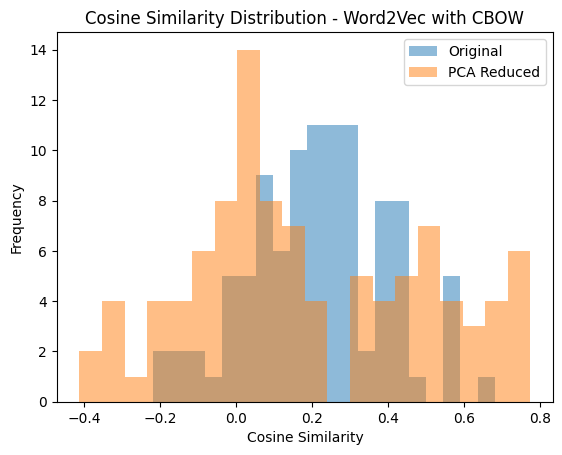

In [54]:
news_plt.figure()
news_plt.hist(original_sim, bins=20, alpha=0.5, label='Original')
news_plt.hist(reduced_sim, bins=20, alpha=0.5, label='PCA Reduced')
news_plt.title("Cosine Similarity Distribution - Word2Vec with CBOW")
news_plt.xlabel("Cosine Similarity")
news_plt.ylabel("Frequency")
news_plt.legend()
news_plt.show()

**Top-K Nearest Neighbor Overlap**

In [55]:
### ------------------- Top-K Neighbor Overlap ---------------------

def get_top_k_original(word, k=5):
    return [w for w, _ in cbow_model.wv.most_similar(word, topn=k)]

def get_top_k_reduced(word, k=5):
    vec = reduced_news_txt_vec[word_list.index(word)].reshape(1, -1)
    sims = cosine_similarity(vec, reduced_news_txt_vec)[0]
    top_k_idx = sims.argsort()[-k-1:-1][::-1]
    return [word_list[i] for i in top_k_idx]

overlaps = []

for word in sample_words:
    orig_neighbors = set(get_top_k_original(word))
    red_neighbors = set(get_top_k_reduced(word))

    overlap = len(orig_neighbors & red_neighbors) / len(orig_neighbors)
    overlaps.append(overlap)

print(f"Average Overlap (Top-5): {np.mean(overlaps):.4f}")

Average Overlap (Top-5): 0.2000


In [56]:
#Build Reduced Embedding Dictionary
word_list = list(cbow_model.wv.index_to_key)

reduced_embedding_dict = {
    word: reduced_news_txt_vec[i] for i, word in enumerate(word_list)
}

# Create PCA Embedding Matrix
embed_matrix_pca = np.zeros((vocab_size, 50))

for word, i in keras_token_news.word_index.items():
    if word in reduced_embedding_dict:
        embed_matrix_pca[i] = reduced_embedding_dict[word]

print("PCA Embedding Matrix Shape:", embed_matrix_pca.shape)

PCA Embedding Matrix Shape: (161005, 50)


# LSTM with PCA Embeddings

In [57]:
lstm_model_cbow_pca = Sequential()

lstm_model_cbow_pca.add(Embedding(
    input_dim=vocab_size,
    output_dim=50,
    weights=[embed_matrix_pca],
    input_length=200,
    trainable=False
))

lstm_model_cbow_pca.add(LSTM(64))
lstm_model_cbow_pca.add(Dense(1, activation='sigmoid'))

lstm_model_cbow_pca.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

start_lstm_train = time.time()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_pca = lstm_model_cbow_pca.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

lstm_pca_training_time = time.time() - start_lstm_train
print(f"\nTraining time of LSTM after dimensionality reduction: {lstm_pca_training_time:.4f} seconds")

Epoch 1/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 146ms/step - accuracy: 0.9353 - loss: 0.1710 - val_accuracy: 0.9410 - val_loss: 0.1500
Epoch 2/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 50s 127ms/step - accuracy: 0.9682 - loss: 0.0927 - val_accuracy: 0.9727 - val_loss: 0.0788
Epoch 3/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 81s 125ms/step - accuracy: 0.9775 - loss: 0.0669 - val_accuracy: 0.9778 - val_loss: 0.0664
Epoch 4/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.9834 - loss: 0.0535 - val_accuracy: 0.9794 - val_loss: 0.0601
Epoch 5/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - accuracy: 0.9865 - loss: 0.0438 - val_accuracy: 0.9816 - val_loss: 0.0558
Epoch 6/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.9871 - loss: 0.0406 - val_accuracy: 0.9797 - val_loss: 0.0620
Epoch 7/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9776 - val_loss: 0.0668

Training time of LSTM after dimensionality reduction: 426.0428 seconds


245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step

Testing Time (PCA): 10.3070 seconds


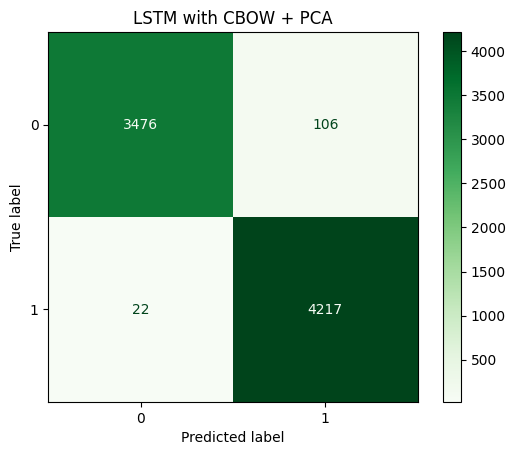

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3582
           1       0.98      0.99      0.99      4239

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821


ROC-AUC Score: 0.9974


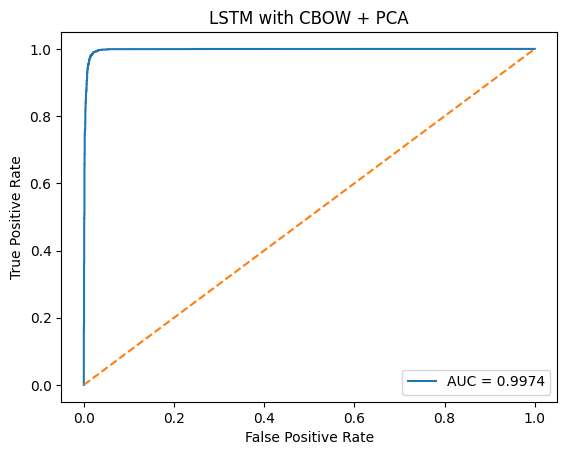

In [58]:
# Prediction time
start_lstm_tst_time = time.time()
y_pred_prob_pca = lstm_model_cbow_pca.predict(X_test)
lstm_predict_time_pca = time.time() - start_lstm_tst_time
print(f"\nTesting Time (PCA): {lstm_predict_time_pca:.4f} seconds")

y_pred_prob_pca = y_pred_prob_pca.ravel()
y_pred_pca = (y_pred_prob_pca > 0.5).astype(int)

news_cm_display = display_cm(cm_news(y_test, y_pred_pca))
news_cm_display.plot(cmap='Greens')
news_plt.title("LSTM with CBOW + PCA")
news_plt.show()

print(cl_report(y_test, y_pred_pca))

auc_pca_score = auc_news(y_test, y_pred_prob_pca)
print(f"\nROC-AUC Score: {auc_pca_score:.4f}")

fpr, tpr, _ = roc_news(y_test, y_pred_prob_pca)
news_plt.figure()
news_plt.plot(fpr, tpr, label=f"AUC = {auc_pca_score:.4f}")
news_plt.plot([0, 1], [0, 1], linestyle='--')
news_plt.title("LSTM with CBOW + PCA")
news_plt.xlabel("False Positive Rate")
news_plt.ylabel("True Positive Rate")
news_plt.legend()
news_plt.show()

# Word2Vec with Skip-gram

**# Training Word2Vec with Skip-gram**

In [59]:
#Training Word2Vec with Skip-gram ONLY on training data
start_skipgram_time = time.time()

Skipgram_model = Word2Vec(
    sentences=X_train_tok,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1   # Skip-gram
)

Skipgram_training_time = time.time() - start_skipgram_time

print(f"\nSkip-gram Training Time: {Skipgram_training_time:.4f} seconds")


Skip-gram Training Time: 661.8013 seconds


In [60]:
keras_token_news = keras_tokenizer()
keras_token_news.fit_on_texts(X_train_news)
X_train_seq = keras_token_news.texts_to_sequences(X_train_news)
X_test_seq = keras_token_news.texts_to_sequences(X_test_news)

print("First two rows of news in the training data after word2vec and tokenisation with keras:\n")
for i in range(2):
    print(f"News {i+1}:", X_train_seq[i])
    print()

First two rows of news in the training data after word2vec and tokenisation with keras:

News 1: [3223, 2398, 41, 1062, 17, 4533, 187, 553, 5352, 2909, 192, 315, 371, 5, 7601, 3671, 28, 3697, 88, 887, 14220, 51, 41, 1062, 91, 101, 39, 57, 911, 7114, 371, 3671, 361, 229, 2, 63665, 329, 315, 6, 2909, 6, 3, 2111, 4, 4326, 18, 1062, 12, 831, 17, 4533, 39, 1645, 3, 195, 4, 3, 187, 553, 515, 52, 437, 46, 1975, 182, 16, 1, 3629, 112, 2197, 50, 18, 63666, 2, 1, 3671, 41, 1062, 17, 963, 2, 1416, 1645, 3, 57, 53, 874, 1489, 5, 17, 963, 2, 31450, 1, 492, 8991, 4, 1, 1885, 31, 1606, 7, 1, 911, 109, 946, 3, 906, 113, 8, 4968, 5, 172, 1524, 8, 2, 97, 116, 4, 339, 63667, 2, 16696, 205, 6, 1, 515, 4, 3, 553, 911, 11, 61, 135, 45, 35, 223, 6521, 33, 1, 3535, 427, 12, 75, 4464, 7, 54, 17, 120, 963, 2, 7040, 2, 1645, 7, 15, 439, 2, 1, 315, 5, 1224, 1, 6419, 4795, 6, 30, 1791, 425, 24, 1, 1323, 5, 3, 71, 25509, 247, 24, 454, 108, 46919, 1, 315, 8495, 7, 1, 964, 4, 1, 715, 441, 46, 2111, 1, 2193, 1, 3223, 

In [61]:
#padding for LSTM
X_train = pad_seq(X_train_seq, maxlen= 200)
X_test = pad_seq(X_test_seq, maxlen= 200)

print("First two rows of news after padding:\n")
for i in range(2):
    print(f"News {i+1}:", X_train[i])
    print()

First two rows of news after padding:

News 1: [  103   487     7  1786     2   467   152  1123     6   731  2775   127
    12    10   332   635     9 10467   135  1983  1594     1  2230  3482
    11    26     1   515    62  4533  1267   162   190     3  6522    11
     1   274  1165 27089    19   731     5  1645    11     3  1489     4
   661   188     2   177    45     3  1489     4     3   300    45    28
    56     2  1228    27    58  1237    55     7    48   874    31    35
   109    23     2   118    39    45   676     2  1228    58   763   226
    43    23     2  2070   263    12  2240    46   830   319    43    62
    23     2  2070   111    45    70   499     2   223  1645     3 21221
  1489    64     1  3916  3150   381    24    17  1281  9120    24 34762
   695     4  6961  1159     1 14483     4     1  1885     2    18  3916
     5  1341     4  8934 12515     4 63668  2172     7    24     3   329
   315   187   553 39527  3671    28  1096     9 28987  1834  4587     1
  44

In [62]:
#Embedding Matrix

vocab_size = len(keras_token_news.word_index) + 1

def lstm_embed_matrix(model):
    embedding_matrix = np.zeros((vocab_size, 300))
    for word, i in keras_token_news.word_index.items():
        if word in model.wv:
            embedding_matrix[i] = model.wv[word]
    return embedding_matrix

Skipgram_embed_matrix = lstm_embed_matrix(Skipgram_model)
print("Embedding Matrix Shape:", Skipgram_embed_matrix.shape)

Embedding Matrix Shape: (161005, 300)


# LSTM trained with text data embedded using word2vec with Skip-gram (without PCA dimensionality reduction)

In [63]:
lstm_model_skipgm = Sequential()

lstm_model_skipgm.add(Embedding(
    input_dim=vocab_size,
    output_dim=300,
    weights=[Skipgram_embed_matrix],
    input_length= 200,
    trainable=False
))

lstm_model_skipgm.add(LSTM(64))
lstm_model_skipgm.add(Dense(1, activation='sigmoid'))

lstm_model_skipgm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

start_lstm_train = time.time()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = lstm_model_skipgm.fit(
    X_train, y_train,
    validation_split=0.2,   # takes 20% of training data for validation
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

lstm_training_time = time.time() - start_lstm_train
print(f"\nLSTM Training Time: {lstm_training_time:.4f} seconds")

Epoch 1/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 113s 275ms/step - accuracy: 0.9300 - loss: 0.1868 - val_accuracy: 0.9540 - val_loss: 0.1240
Epoch 2/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 139s 268ms/step - accuracy: 0.9477 - loss: 0.1447 - val_accuracy: 0.9449 - val_loss: 0.1345
Epoch 3/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 103s 263ms/step - accuracy: 0.9549 - loss: 0.1257 - val_accuracy: 0.9700 - val_loss: 0.0888
Epoch 4/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 105s 267ms/step - accuracy: 0.9730 - loss: 0.0758 - val_accuracy: 0.9803 - val_loss: 0.0585
Epoch 5/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 142s 268ms/step - accuracy: 0.9847 - loss: 0.0463 - val_accuracy: 0.9823 - val_loss: 0.0540
Epoch 6/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 104s 265ms/step - accuracy: 0.9870 - loss: 0.0376 - val_accuracy: 0.9853 - val_loss: 0.0416
Epoch 7/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 141s 263ms/step - accuracy: 0.9891 - loss: 0.0324 - val_accuracy: 0.9875 - val_loss: 0.0418
Epoch 8/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 104s 265ms/step - accuracy: 0.9915 -

245/245 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step

Testing (Prediction) time: 18.6386 seconds


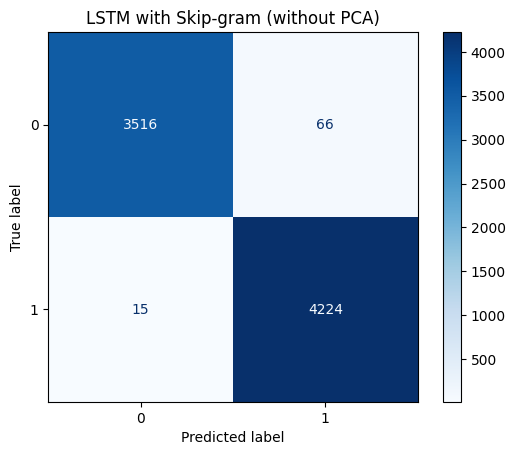

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3582
           1       0.98      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821


ROC-AUC Score: 0.9990


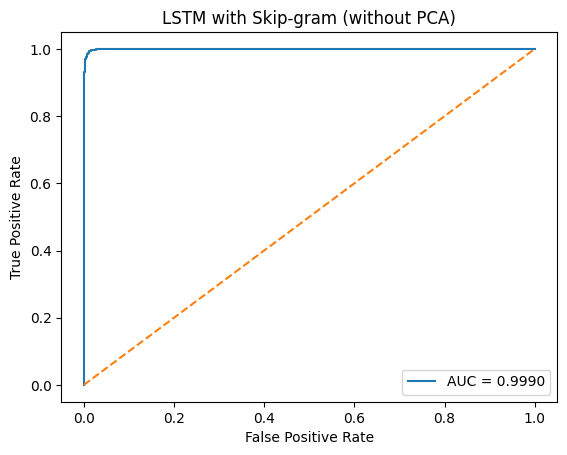

In [64]:
# Testing LSTM
start_lstm_tst_time = time.time()
y_pred_prob = lstm_model_skipgm.predict(X_test)
lstm_predict_time = time.time() - start_lstm_tst_time
print(f"\nTesting (Prediction) time: {lstm_predict_time:.4f} seconds")


# Converting Probabilities to Class labels
y_pred_prob = y_pred_prob.ravel()   # flatten
y_pred = (y_pred_prob > 0.5).astype(int)


# Confusion Matrix
news_cm_display = display_cm(cm_news(y_test, y_pred))   # Confusion Matrix
news_cm_display.plot(cmap='Blues')
news_plt.title("LSTM with Skip-gram (without PCA)")
news_plt.show()


# ---------   Classifcation report with accuracy, precision, recall  and f1 score
print(cl_report(y_test, y_pred))

# ---------   Measuring the ROC-AUC Score and Plotting the ROC Curve

auc_score = auc_news(y_test, y_pred_prob)   # ROC-AUC Score
print(f"\nROC-AUC Score: {auc_score:.4f}")


fpr, tpr, thresholds = roc_news(y_test, y_pred_prob)
news_plt.figure()
news_plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
news_plt.plot([0, 1], [0, 1], linestyle='--')
news_plt.xlabel("False Positive Rate")
news_plt.ylabel("True Positive Rate")
news_plt.title("LSTM with Skip-gram (without PCA)")
news_plt.legend()
news_plt.show()


# Dimensionality reduction using  PCA with n_components = 50 on Word2Vec with Skip-gram embeddings

In [65]:
# Extract Word2Vec vectors
w2v_skipgm_news_vec = Skipgram_model.wv.vectors

# pca dimensionality reduction
dimension_reduce_pca = PCA(n_components= 50)
reduced_news_txt_vec = dimension_reduce_pca.fit_transform(w2v_skipgm_news_vec)

print("Shape before dimensionality reduction:", w2v_skipgm_news_vec.shape)
print("Shape after dimensionality reduction using PCA:", reduced_news_txt_vec.shape)

Shape before dimensionality reduction: (63664, 300)
Shape after dimensionality reduction using PCA: (63664, 50)


**Explained Variance Ratio**

In [66]:
# ---------------------  Meausring Explained Variance Ratio ---------------------

explained_variance = np.sum(dimension_reduce_pca.explained_variance_ratio_)
print(f"Total Explained Variance (50D): {explained_variance:.4f}")

Total Explained Variance (50D): 0.5843


After PCA, 58.43% of the original information is retained.

**Cosine Similarity Preservation**

In [67]:

### ----------- Semantic Preservation using Cosine Similarity -----------

word_list = list(Skipgram_model.wv.index_to_key)

# sample words
sample_words = random.sample(word_list, 100)

original_sim = []
reduced_sim = []

for word in sample_words:
    other = random.choice(word_list)

    # Original vectors
    orig1 = Skipgram_model.wv[word].reshape(1, -1)
    orig2 = Skipgram_model.wv[other].reshape(1, -1)

    # PCA reduced vectors
    red1 = reduced_news_txt_vec[word_list.index(word)].reshape(1, -1)
    red2 = reduced_news_txt_vec[word_list.index(other)].reshape(1, -1)

    original_sim.append(cosine_similarity(orig1, orig2)[0][0])
    reduced_sim.append(cosine_similarity(red1, red2)[0][0])

# Average cosine similarity
orig_mean = np.mean(original_sim)
red_mean = np.mean(reduced_sim)

print(f"Original similarity (before PCA): {orig_mean:.4f}")
print(f"Reduced similarity (after PCA): {red_mean:.4f}")

Original similarity (before PCA): 0.5420
Reduced similarity (after PCA): 0.0693


news_plt.figure()
news_plt.hist(original_sim, bins=20, alpha=0.5, label='Original')
news_plt.hist(reduced_sim, bins=20, alpha=0.5, label='PCA Reduced')
news_plt.title("Cosine Similarity Distribution - Word2Vec with Skipgram")
news_plt.xlabel("Cosine Similarity")
news_plt.ylabel("Frequency")
news_plt.legend()
news_plt.show()

**Top-K Nearest Neighbor Overlap**

In [68]:
### ------------------- Top-K Neighbor Overlap ---------------------

def get_top_k_original(word, k=5):
    return [w for w, _ in Skipgram_model.wv.most_similar(word, topn=k)]

def get_top_k_reduced(word, k=5):
    vec = reduced_news_txt_vec[word_list.index(word)].reshape(1, -1)
    sims = cosine_similarity(vec, reduced_news_txt_vec)[0]
    top_k_idx = sims.argsort()[-k-1:-1][::-1]
    return [word_list[i] for i in top_k_idx]

overlaps = []

for word in sample_words:
    orig_neighbors = set(get_top_k_original(word))
    red_neighbors = set(get_top_k_reduced(word))

    overlap = len(orig_neighbors & red_neighbors) / len(orig_neighbors)
    overlaps.append(overlap)

print(f"Average Overlap (Top-5): {np.mean(overlaps):.4f}")

Average Overlap (Top-5): 0.2860


In [69]:
#Build Reduced Embedding Dictionary
word_list = list(Skipgram_model.wv.index_to_key)

reduced_embedding_dict = {
    word: reduced_news_txt_vec[i] for i, word in enumerate(word_list)
}

# Create PCA Embedding Matrix
embed_matrix_pca = np.zeros((vocab_size, 50))

for word, i in keras_token_news.word_index.items():
    if word in reduced_embedding_dict:
        embed_matrix_pca[i] = reduced_embedding_dict[word]

print("PCA Embedding Matrix Shape:", embed_matrix_pca.shape)

PCA Embedding Matrix Shape: (161005, 50)


# LSTM with PCA Embeddings

In [70]:
lstm_model_skipgm_pca = Sequential()

lstm_model_skipgm_pca.add(Embedding(
    input_dim=vocab_size,
    output_dim=50,
    weights=[embed_matrix_pca],
    input_length=200,
    trainable=False
))

lstm_model_skipgm_pca.add(LSTM(64))
lstm_model_skipgm_pca.add(Dense(1, activation='sigmoid'))

lstm_model_skipgm_pca.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

start_lstm_train = time.time()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_pca = lstm_model_skipgm_pca.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

lstm_pca_training_time = time.time() - start_lstm_train
print(f"\nTraining time of LSTM after dimensionality reduction: {lstm_pca_training_time:.4f} seconds")

Epoch 1/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step - accuracy: 0.9356 - loss: 0.1745 - val_accuracy: 0.9693 - val_loss: 0.0985
Epoch 2/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 132ms/step - accuracy: 0.9639 - loss: 0.1047 - val_accuracy: 0.9688 - val_loss: 0.0899
Epoch 3/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - accuracy: 0.9682 - loss: 0.0934 - val_accuracy: 0.9637 - val_loss: 0.1128
Epoch 4/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.9714 - loss: 0.0834 - val_accuracy: 0.9738 - val_loss: 0.0807
Epoch 5/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 81s 131ms/step - accuracy: 0.9740 - loss: 0.0765 - val_accuracy: 0.9712 - val_loss: 0.0892
Epoch 6/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.9769 - loss: 0.0674 - val_accuracy: 0.9752 - val_loss: 0.0748
Epoch 7/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.9706 - loss: 0.0852 - val_accuracy: 0.9771 - val_loss: 0.0773
Epoch 8/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 80s 129ms/step - accuracy: 0.9762 - loss: 0

245/245 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step

Testing Time (PCA): 10.3248 seconds


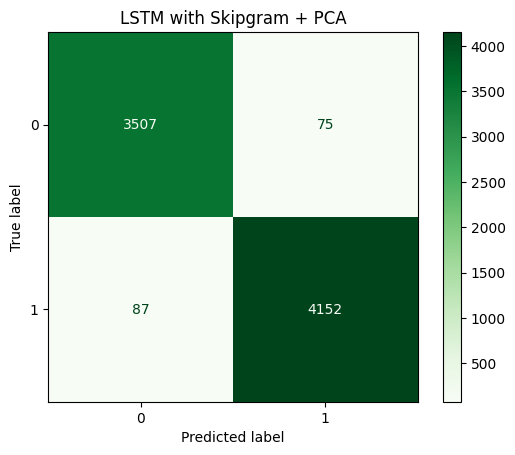

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3582
           1       0.98      0.98      0.98      4239

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821


ROC-AUC Score: 0.9970


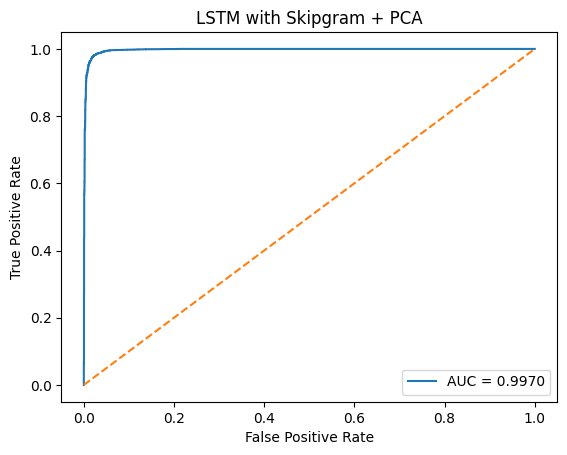

In [71]:
# Prediction time
start_lstm_tst_time = time.time()
y_pred_prob_pca = lstm_model_skipgm_pca.predict(X_test)
lstm_predict_time_pca = time.time() - start_lstm_tst_time
print(f"\nTesting Time (PCA): {lstm_predict_time_pca:.4f} seconds")

y_pred_prob_pca = y_pred_prob_pca.ravel()
y_pred_pca = (y_pred_prob_pca > 0.5).astype(int)

news_cm_display = display_cm(cm_news(y_test, y_pred_pca))
news_cm_display.plot(cmap='Greens')
news_plt.title("LSTM with Skipgram + PCA")
news_plt.show()

print(cl_report(y_test, y_pred_pca))

auc_pca_score = auc_news(y_test, y_pred_prob_pca)
print(f"\nROC-AUC Score: {auc_pca_score:.4f}")

fpr, tpr, _ = roc_news(y_test, y_pred_prob_pca)
news_plt.figure()
news_plt.plot(fpr, tpr, label=f"AUC = {auc_pca_score:.4f}")
news_plt.plot([0, 1], [0, 1], linestyle='--')
news_plt.title("LSTM with Skipgram + PCA")
news_plt.xlabel("False Positive Rate")
news_plt.ylabel("True Positive Rate")
news_plt.legend()
news_plt.show()